# FLIR ADAS v2 Dataset Check

Objective: confirm that the thermal frames used for restoration experiments load as single-channel `float32` arrays on the 8-bit-equivalent scale (0-255), group by video sequence, and split by sequence without leakage.

Data: FLIR ADAS v2 thermal 14-bit TIFFs (`data/FLIR_ADAS_v2`, train, val and video test parts combined). Method: every step goes through `thermal_restore.data`; nothing is defined in the notebook. Headline result: 158 sequences and 15,635 frames, with a disjoint 70/15/15 split by sequence.

## Setup

In [6]:
from pathlib import Path

import numpy as np

from thermal_restore.data.loader import (
    frame_index,
    list_sequences,
    load_frame,
    sample_frames,
)
from thermal_restore.data.split import split_by_sequence
from thermal_restore.data.visualization import plot_frame_grid

DATA_ROOT = Path("../data/FLIR_ADAS_v2")
SEED = 0
N_SAMPLES = 10

## Data

### Sequences

In [7]:
sequences = list_sequences(DATA_ROOT)
lengths = [len(paths) for paths in sequences.values()]
print(f"{len(sequences)} sequences, {sum(lengths)} frames")
print(
    f"frames per sequence: min {min(lengths)}, "
    f"median {int(np.median(lengths))}, max {max(lengths)}"
)

158 sequences, 15635 frames
frames per sequence: min 3, median 55, max 1033


### Split by Sequence

Neighbouring frames of one sequence are nearly identical, so a frame-level split would leak test content into training. Each sequence must land in exactly one set.

In [8]:
split = split_by_sequence(list(sequences), seed=SEED)
for name, ids in split.items():
    n_frames = sum(len(sequences[i]) for i in ids)
    print(f"{name:5s} {len(ids):4d} sequences, {n_frames:6d} frames")

all_ids = [i for ids in split.values() for i in ids]
assert len(all_ids) == len(set(all_ids)) == len(sequences)

train  111 sequences,   9564 frames
val     24 sequences,   2761 frames
test    23 sequences,   3310 frames


### Random Frames

Frames are shown as returned by `load_frame` (0-255 scale). Each image is stretched to its own 1st-99th percentile for display only, because a thermal frame occupies a narrow band of the range. Titles give the sequence id prefix, frame number, and raw min-max.

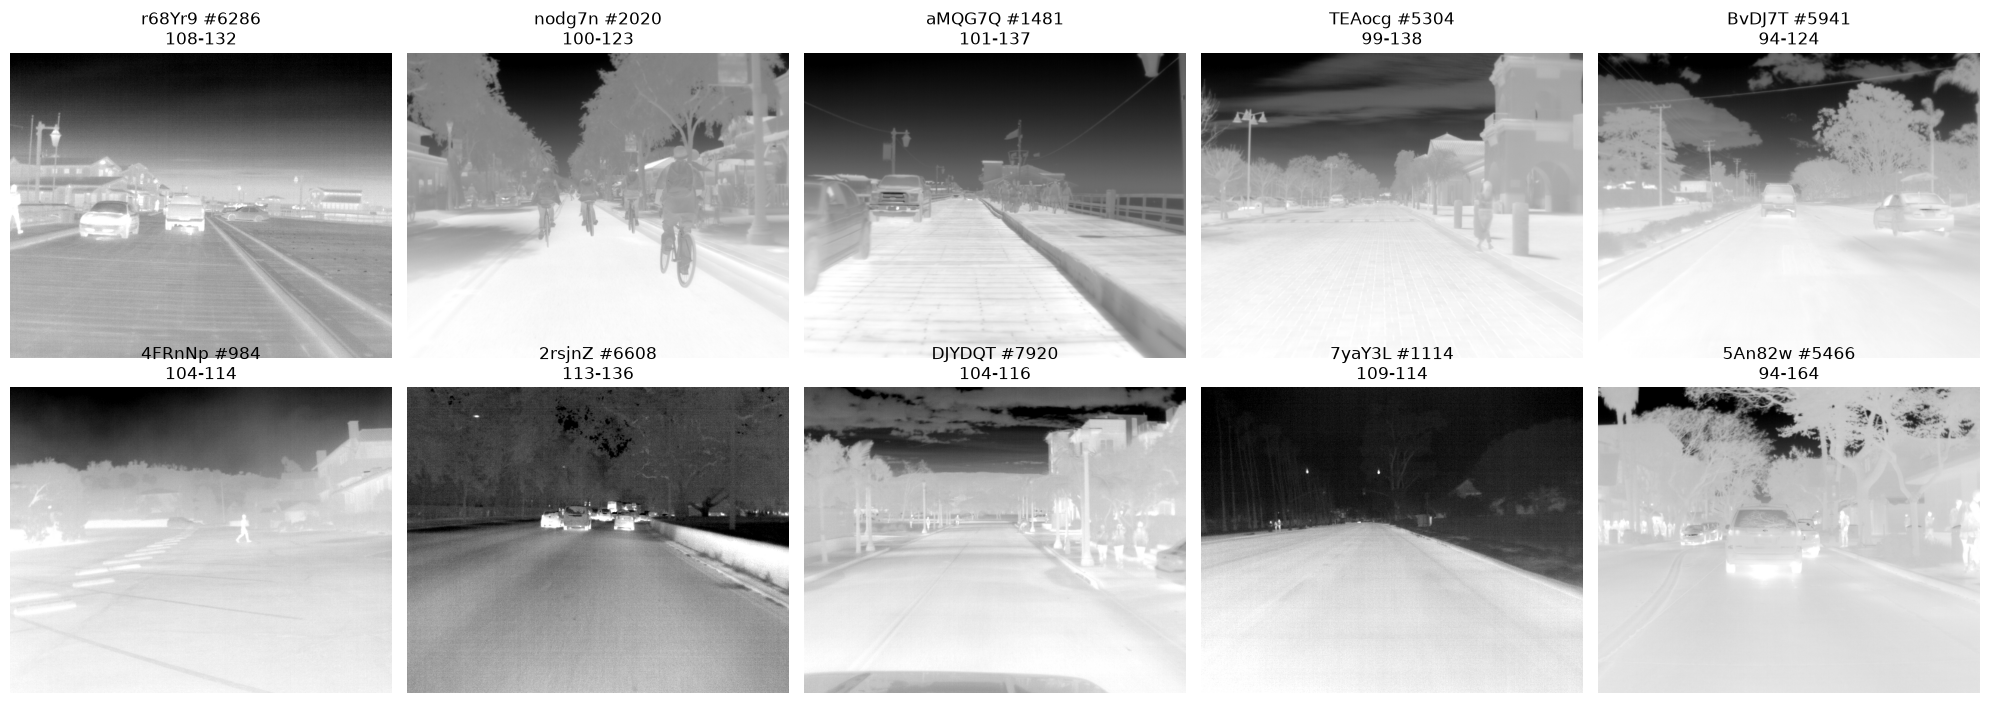

In [9]:
picks = sample_frames(sequences, n=N_SAMPLES, seed=SEED)
frames = [load_frame(path) for _, path in picks]
titles = [
    f"{seq[6:12]} #{frame_index(path)}\n{f.min():.0f}-{f.max():.0f}"
    for (seq, path), f in zip(picks, frames)
]
plot_frame_grid(frames, titles, ncols=5);

### Format and Range

In [10]:
spans = [f.max() - f.min() for f in frames]
for f in frames:
    assert f.dtype == np.float32 and f.ndim == 2
    assert 0.0 <= f.min() and f.max() <= 255.0
print(
    f"shape {frames[0].shape}, values {min(f.min() for f in frames):.0f}"
    f"-{max(f.max() for f in frames):.0f}"
)
print(
    f"within-frame span: mean {np.mean(spans):.1f}, "
    f"min {min(spans):.1f}, max {max(spans):.1f} of 255 levels"
)

shape (512, 640), values 94-164
within-frame span: mean 27.3, min 5.4, max 69.9 of 255 levels
